## 1. EDA (Exploratory Data Analysis)

Оптимизированный профиль рынка конкурентов:
                                 Product_Name  Shore_A_min  Shore_A_max  \
0                      SikaHyflex®-250 Facade         20.0         20.0   
1        Герметик полиуретановый MASTERFIX-PU         25.0         35.0   
2             Полиуретановый клей-герметик PU         20.0         20.0   
3  Полиуретановый строительный клей-герметик.         35.0         45.0   

   Shore_A_mean  Elongation_mean  
0          20.0            800.0  
1          30.0            600.0  
2          20.0            600.0  
3          40.0            740.0  


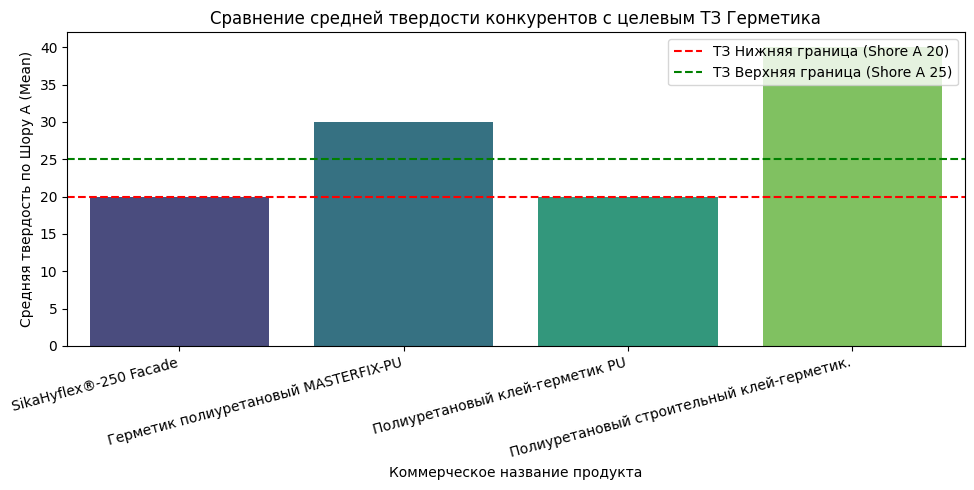

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загружаем обновленный ML-ready датасет
df = pd.read_csv('../data/03_processed/benchmarks_dataset.csv')

# Очищаем дубликаты по обновленным именам колонок
df = df.drop_duplicates(subset=['Product_Name', 'Shore_A_mean'])

print("Оптимизированный профиль рынка конкурентов:")
print(df[['Product_Name', 'Shore_A_min', 'Shore_A_max', 'Shore_A_mean', 'Elongation_mean']])

# 2. Построение графика по средним значениям твердости
plt.figure(figsize=(10, 5))

sns.barplot(
    x='Product_Name', 
    y='Shore_A_mean', 
    data=df, 
    hue='Product_Name', 
    palette='viridis', 
    legend=False
)

# Добавляем целевые границы по нашему ТЗ (20-25 по Шору А)
plt.axhline(y=20, color='r', linestyle='--', linewidth=1.5, label='ТЗ Нижняя граница (Shore A 20)')
plt.axhline(y=25, color='g', linestyle='--', linewidth=1.5, label='ТЗ Верхняя граница (Shore A 25)')

plt.title('Сравнение средней твердости конкурентов с целевым ТЗ Герметика')
plt.ylabel('Средняя твердость по Шору А (Mean)')
plt.xlabel('Коммерческое название продукта')
plt.xticks(rotation=15, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

## 2. Запуск симуляции пространства рецептур

In [10]:
import sys
import os
import pandas as pd
import numpy as np

# Добавляем путь к src в sys.path, чтобы импортировать наш калькулятор
sys.path.append(os.path.abspath('../src'))
from features.pu_calculator import PolyurethaneCalculator

# Задаем константы для сырья
MDI_MW = 250.25  # Молекулярная масса 4,4'-MDI

# Генерируем пространство параметров для симуляции
polyol_options = [2000, 3000, 4000]  # Молекулярные массы промышленных ППГ-диолов
nco_indices = np.linspace(1.5, 2.2, 8)  # Шаг изменения NCO/OH индекса от 1.5 до 2.2

results = []

for mw in polyol_options:
    for index in nco_indices:
        calc_res = PolyurethaneCalculator.calculate_formulation(
            polyol_mw=mw,
            polyol_func=2.0,  # работаем с диолами для высокой эластичности
            diisocyanate_mw=MDI_MW,
            nco_index=index
        )
        calc_res["Polyol_Mw"] = mw
        results.append(calc_res)

# Превращаем результаты симуляции в DataFrame
sim_df = pd.DataFrame(results)

# Выведем срез данных, например для длинного диола ППГ-4000
print("Варианты синтеза форполимера на основе ППГ-4000 (на 100г полиола):")
print(sim_df[sim_df['Polyol_Mw'] == 4000][['NCO_OH_Index', 'Isocyanate_Mass_g', 'Theoretical_Free_NCO_Percent']])

Варианты синтеза форполимера на основе ППГ-4000 (на 100г полиола):
    NCO_OH_Index  Isocyanate_Mass_g  Theoretical_Free_NCO_Percent
16           1.5               9.38                          0.96
17           1.6              10.01                          1.15
18           1.7              10.64                          1.33
19           1.8              11.26                          1.51
20           1.9              11.89                          1.69
21           2.0              12.51                          1.87
22           2.1              13.14                          2.04
23           2.2              13.76                          2.22
